# SHEETAL PATIL | DECISION TREE

**Objective:**
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

This comprehensive analysis of the Heart Disease dataset covers data preparation, exploratory analysis, feature engineering, and the implementation of an optimized Decision Tree Classification model.

age	Age in years
Gender	Gender ; Male - 1, Female -0
cp	Chest pain type
trestbps	Resting blood pressure
chol	cholesterol measure
fbs	(fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
restecg	"ecg observation at resting condition,   -- Value 0: normal
        -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
        -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria"
thalch	maximum heart rate achieved
exang	exercise induced angina
oldpeak	ST depression induced by exercise relative to rest
slope	the slope of the peak exercise ST segment
thal	Thal
num	target [0=no heart disease; 1,2,3,4 = stages of heart disease ]


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [33]:
# Load the dataset
df = pd.read_csv("D:\\Work\\ExcelRCource\\Assignments\\13 Decision Tree\\heart_disease.csv")

In [34]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,FALSE,1.5,upsloping,fixed defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,TRUE,3.0,flat,fixed defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,TRUE,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,normal,4


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [36]:
print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [38]:
df[df.duplicated()].shape

(1, 13)

In [39]:
#Count of Duplicated data
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
765,58,Male,non-anginal,150,219,False,st-t abnormality,118,TRUE,0.0,downsloping,reversable defect,2


In [40]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [41]:
df.describe(include='object')

,sex,cp,restecg,exang,slope,thal
count,908,908,908,908,908,908
unique,2,4,3,3,3,3
top,Male,asymptomatic,normal,FALSE,flat,normal
freq,718,495,542,535,453,348


In [42]:
# Distribution of target
print("Target distribution:")
df['num'].value_counts()

Target distribution:


num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Categorical Feature Relationships
Analyzing categorical variables against the heart disease stages (num) reveals strong indicators:

**Chest Pain Type (cp):** Patients reporting "asymptomatic" chest pain are significantly more likely to have higher stages of heart disease. Interestingly, those with "typical angina" or "non-anginal" pain are more frequently in Stage 0 (no disease).

**Sex:** There is a clear disparity; male patients in this dataset show a much higher incidence and higher stages of heart disease compared to female patients.

**Thal:** "Normal" results are highly associated with Stage 0, whereas "reversable defect" is a strong indicator of existing heart disease.

In [43]:
# Check unique values for categorical features
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in cat_cols:
    print(f"\nUnique values for {col}:")
    print(df[col].unique())


Unique values for sex:
['Male' 'Female']

Unique values for cp:
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']

Unique values for fbs:
[ True False]

Unique values for restecg:
['lv hypertrophy' 'normal' 'st-t abnormality']

Unique values for exang:
['FALSE' 'TRUE' 'TURE']

Unique values for slope:
['downsloping' 'flat' 'upsloping']

Unique values for thal:
['fixed defect' 'normal' 'reversable defect']


We need to fix 'exang' column values

### Exploratory Data Analysis

**Target Distribution:** The dataset is somewhat imbalanced across the stages of heart disease (num). Stage 0 (no disease) is the most frequent, while Stage 4 is the least common.

<Axes: xlabel='num'>

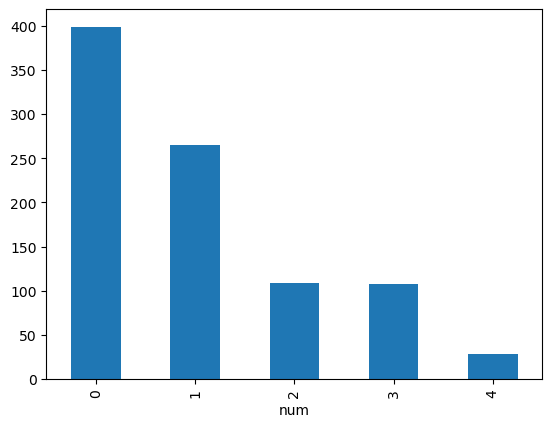

In [67]:
df['num'].value_counts().plot.bar()

Numerical features often show trends as the severity of the disease increases:

**Maximum Heart Rate (thalch):** There is a clear downward trend; as heart rate capacity decreases, the stage of heart disease tends to increase.

**Oldpeak (ST Depression):** Higher levels of ST depression induced by exercise are strongly correlated with more advanced heart disease stages (Stages 2, 3, and 4).

**Age:** While heart disease can occur at any age, the prevalence of Stages 1-4 increases significantly after the age of 50.

**Numerical Features:** Most numerical features like age and trestbps follow a near-normal distribution, though chol, oldpeak shows some right-skewness.

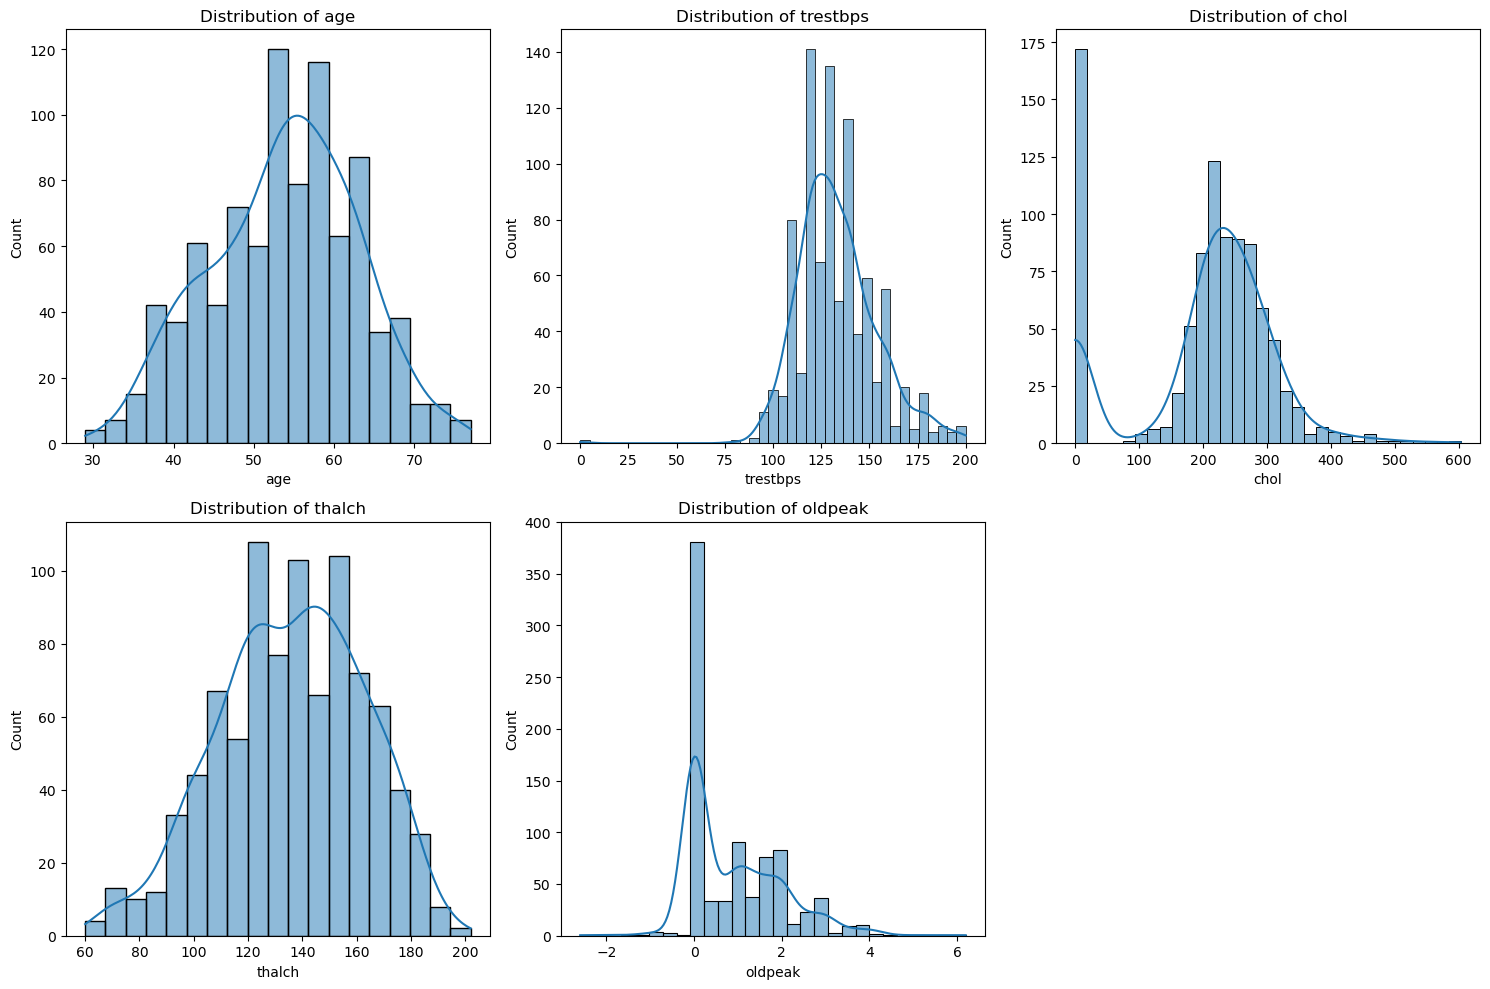

In [44]:
# Visualization
plt.figure(figsize=(15, 10))

# Histograms for numerical columns
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

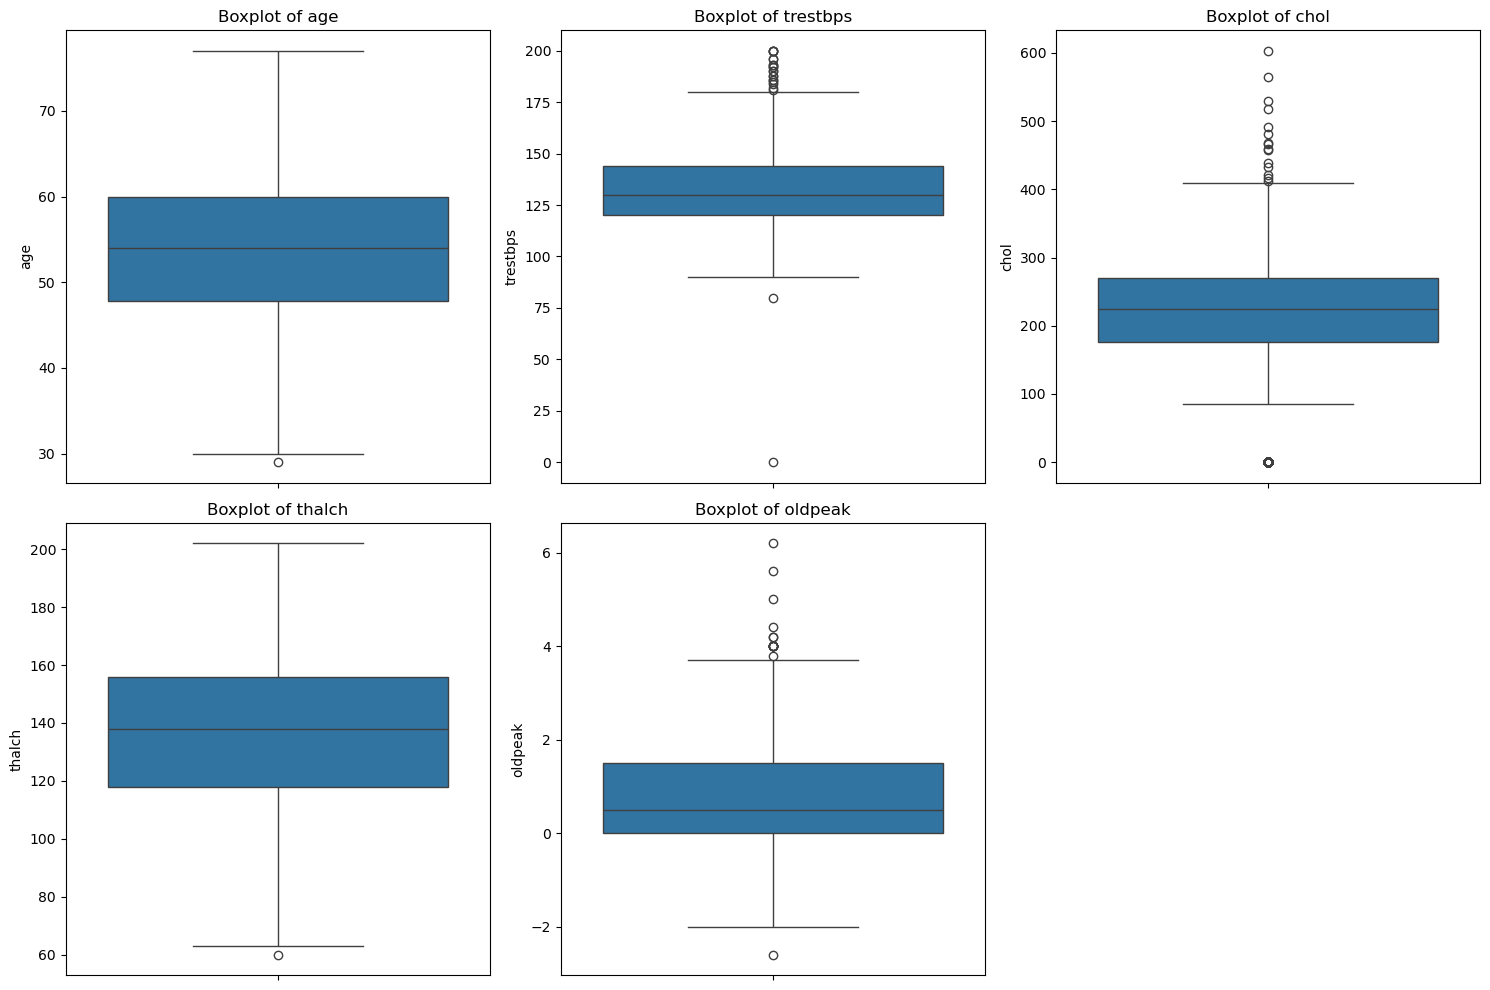

In [45]:
# Boxplots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

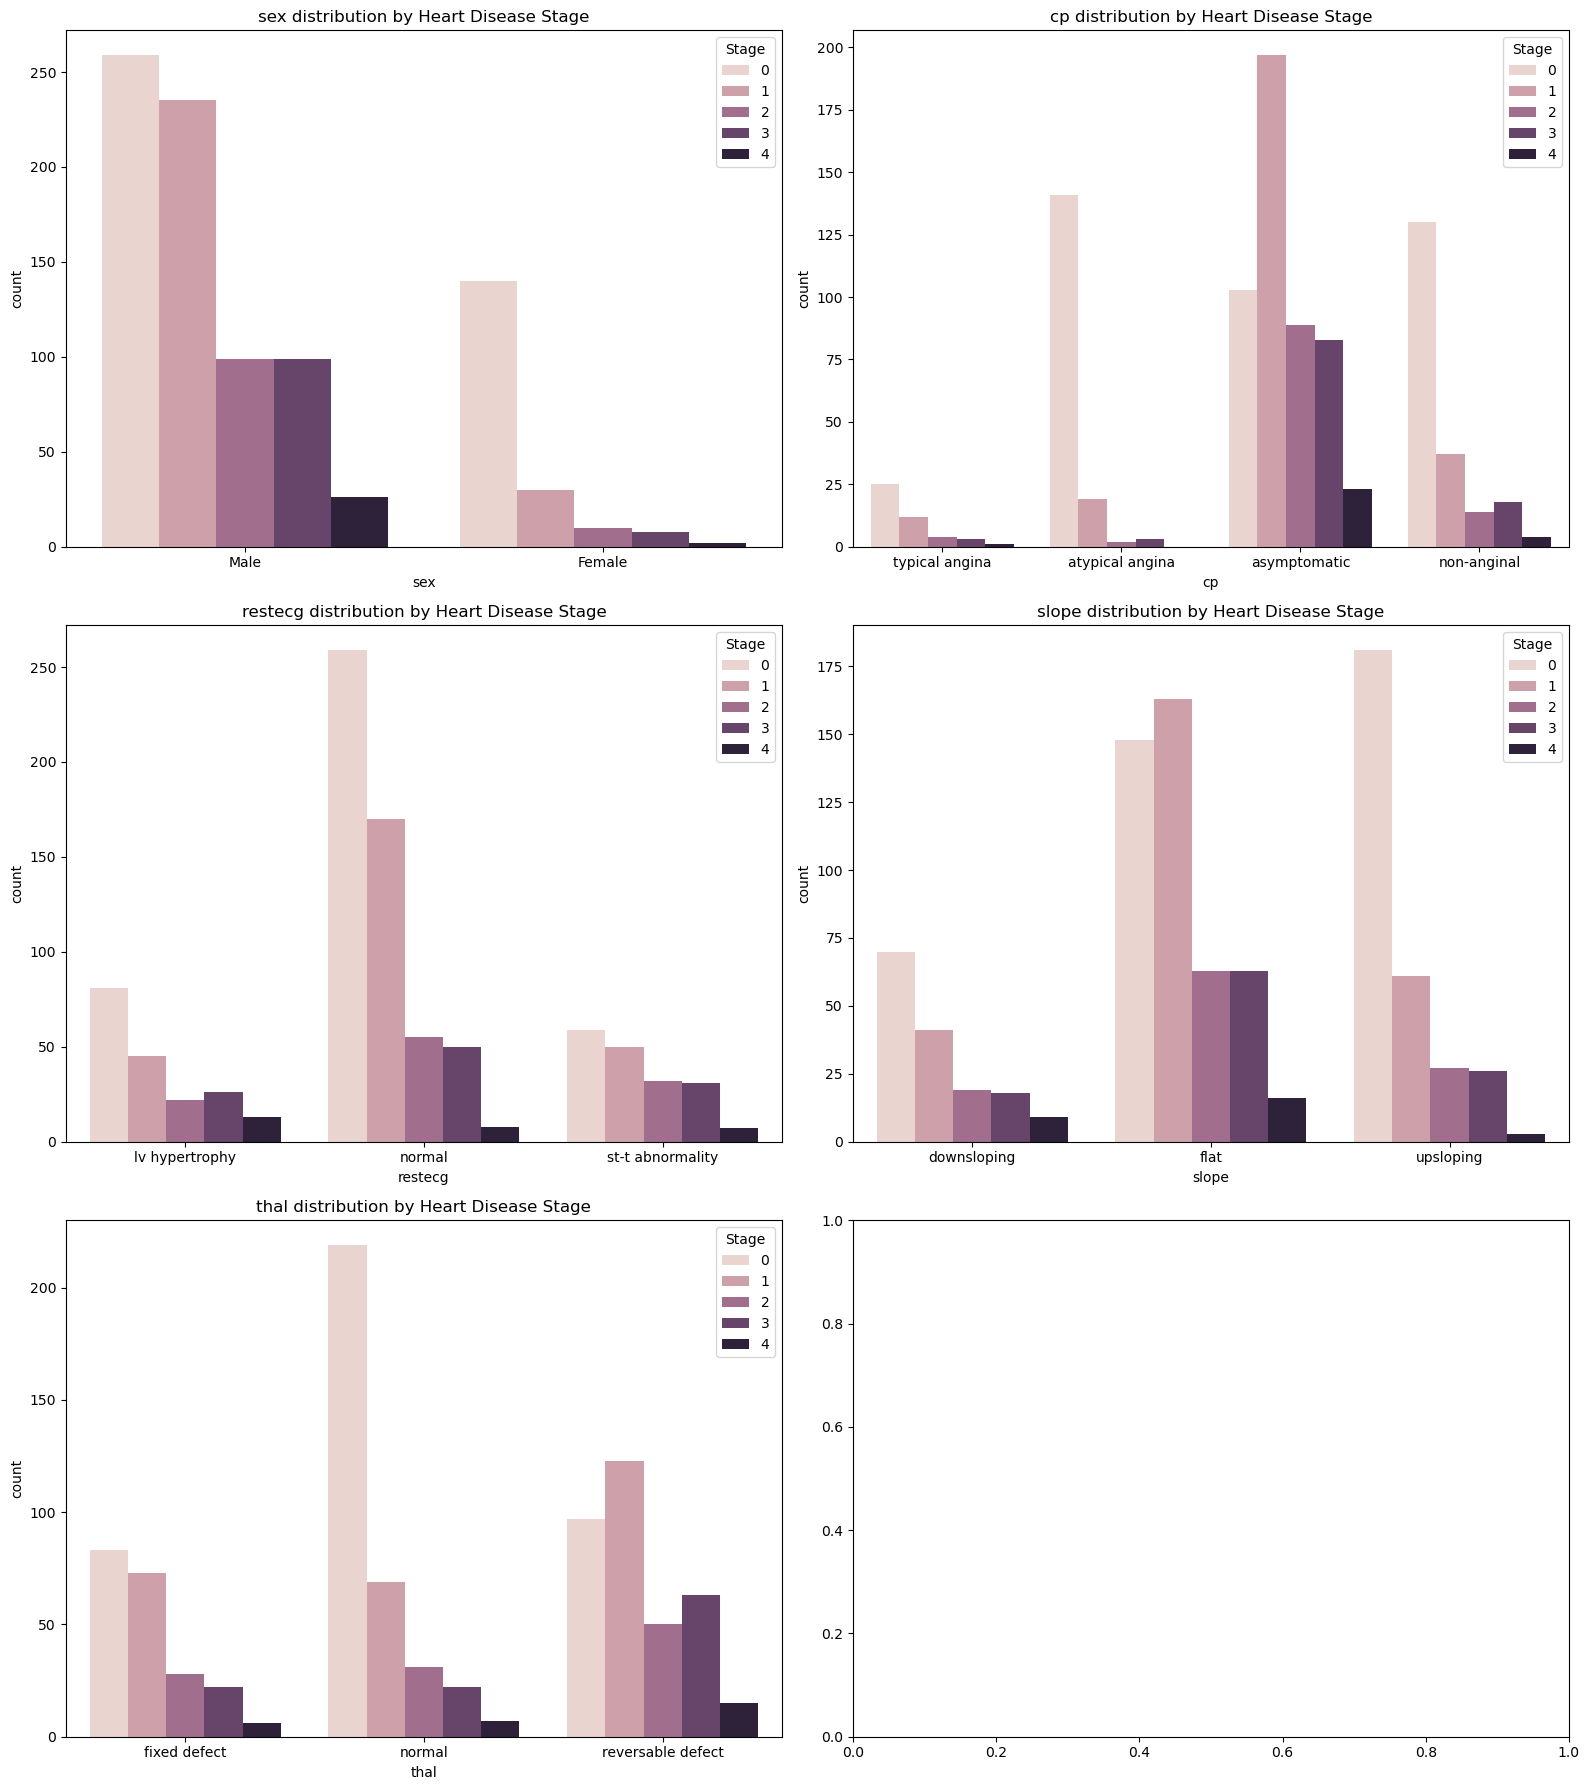

In [73]:
#  Categorical Features vs Target (num)
cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='num', ax=axes[i])
    axes[i].set_title(f'{col} distribution by Heart Disease Stage')
    axes[i].legend(title='Stage', loc='upper right')

plt.tight_layout()
plt.show()

**Demographic Insights**
Gender Prevalence: A binary view (Disease vs. No Disease) confirms that males are disproportionately affected in this specific cohort, which aligns with clinical observations regarding heart disease risk factors.

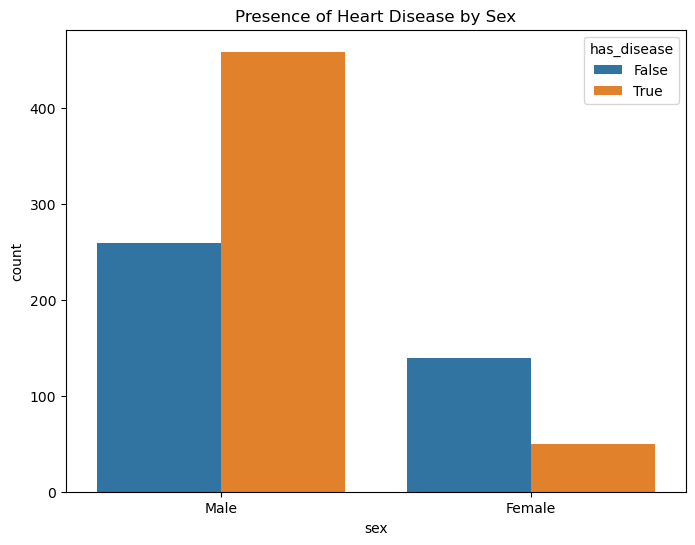

In [72]:
# Target Distribution by Sex (Binary view: Presence vs Absence)
df['has_disease'] = df['num'] > 0
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sex', hue='has_disease')
plt.title('Presence of Heart Disease by Sex')
plt.show()

**Demographic Insights**
Age Groups: When binned into decades, the "50s" and "60s" age groups represent the peak for heart disease diagnosis. Patients in their "30s" are predominantly in the Stage 0 (healthy) category.

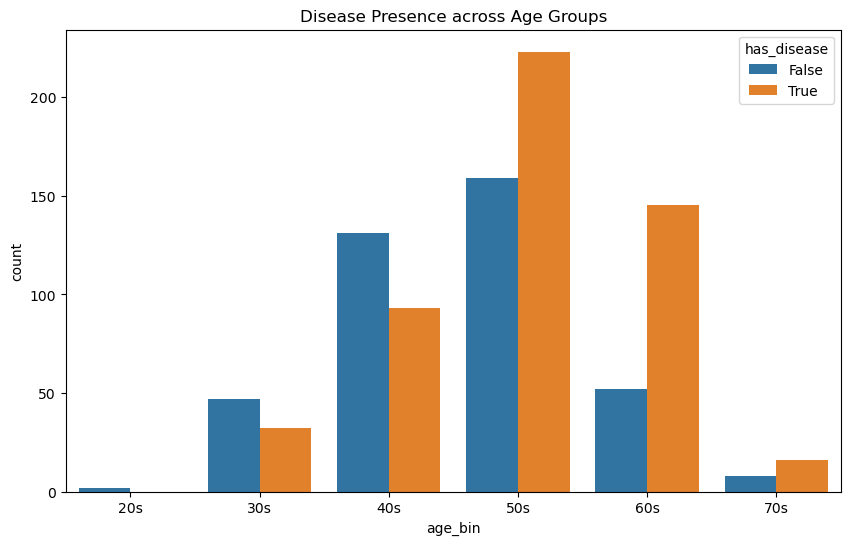

In [74]:
# Age Bins vs Disease Presence
df['age_bin'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20s', '30s', '40s', '50s', '60s', '70s'])
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_bin', hue='has_disease')
plt.title('Disease Presence across Age Groups')
plt.show()

**Multivariate Analysis (Pairplots)**
The pairplot analysis shows that no single numerical feature can perfectly separate the disease stages. Instead, it is the combination of features—such as low thalch combined with high oldpeak and advanced age—that creates a distinct profile for heart disease patients. This complexity justifies the use of a Decision Tree, which can capture these non-linear interactions.

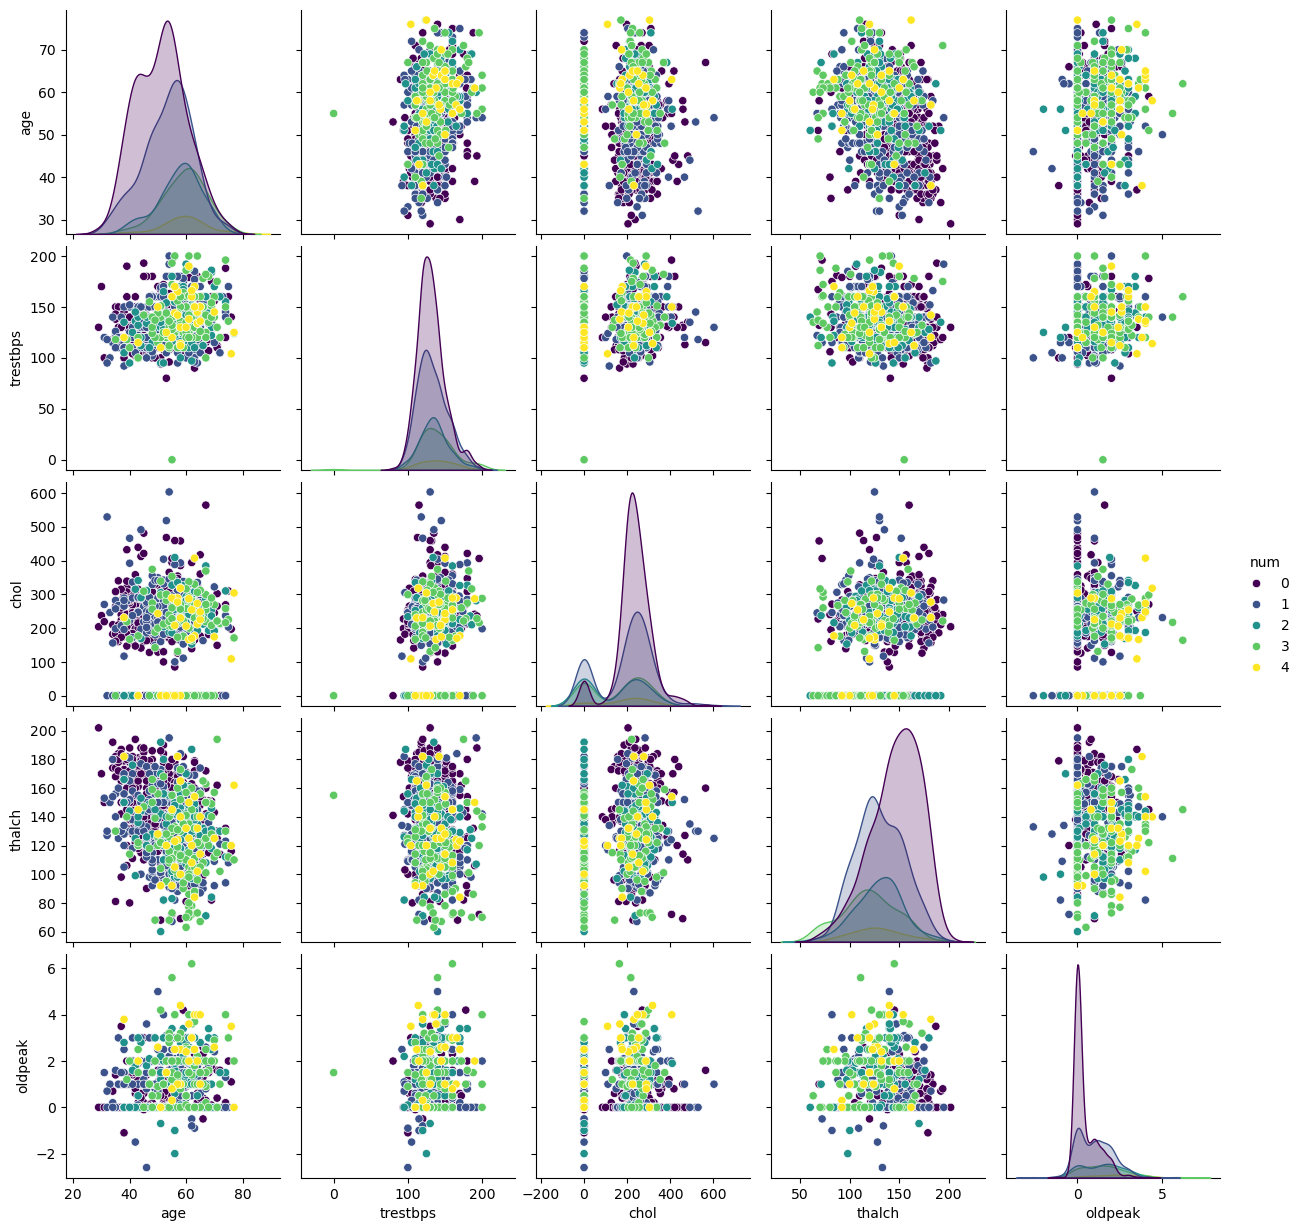

In [75]:
# Pairplot for key numerical features
# Sample a bit if it's too large, but 908 is fine.
sns.pairplot(df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']], hue='num', palette='viridis')
plt.show()

**Correlation Matrix:** Displays how features relate to the target and each other.

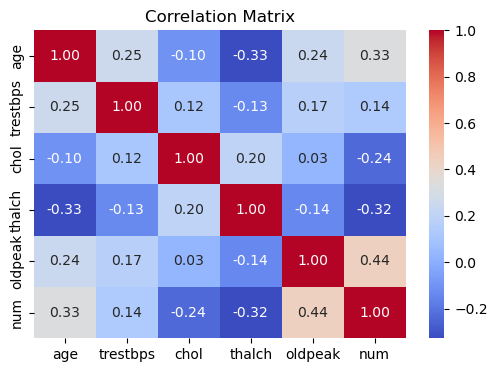

In [46]:
# Correlation Matrix
plt.figure(figsize=(6, 4))
# Need to encode first for correlation with target or just select numerical
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### Data Preparation and Cleaning
Upon initial inspection, the dataset contains 908 records with 13 features. Several data quality issues were addressed:

In [49]:
# Copy for data cleaning
df_clean = df.copy()

**Inconsistent Values:** The exang (exercise-induced angina) column contained inconsistent strings (e.g., 'TURE', 'FALSE', 'True', 'False'). These were standardized to boolean values.

In [50]:
# 1. Handle inconsistent categorical values
# Fix 'exang'
df_clean['exang'] = df_clean['exang'].replace({'TURE': 'True', 'FALSE': 'False', 'True': 'True', 'False': 'False'})
df_clean['exang'] = df_clean['exang'].map({'True': True, 'False': False})

**Outliers/Zero Values:** trestbps (resting blood pressure) and chol (cholesterol) contained 0 values, which are medically impossible. These were treated as missing and imputed with the median of their respective columns.

In [51]:
# 2. Handle 0s in numerical cols (impute with median)
df_clean['trestbps'] = df_clean['trestbps'].replace(0, np.nan)
df_clean['chol'] = df_clean['chol'].replace(0, np.nan)

**Missing Values:** The oldpeak column had 62 missing values, which were imputed using the median.

In [52]:
# 3. Impute missing values (median for numerical, mode for categorical if any)
df_clean['oldpeak'] = df_clean['oldpeak'].fillna(df_clean['oldpeak'].median())
df_clean['trestbps'] = df_clean['trestbps'].fillna(df_clean['trestbps'].median())
df_clean['chol'] = df_clean['chol'].fillna(df_clean['chol'].median())

**Encoding:** Categorical variables such as cp (chest pain type), restecg, slope, and thal were transformed using One-Hot Encoding to make them suitable for the Decision Tree algorithm.

In [54]:
# 4. Encoding categorical variables
# Using LabelEncoding for simple Decision Tree (or One-Hot)
# Let's use One-Hot for cp, restecg, slope, thal. Sex and exang and fbs are binary.
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

### Decision Tree Classification
The dataset was split into an 80% training set and a 20% testing set. A Decision Tree Classifier was initially trained and then optimized using hyperparameter tuning.

The decision tree learns rules based on feature thresholds. For example, the first few splits often involve thal, oldpeak, or cp, indicating these are primary indicators of heart disease.

In [55]:
# 5. Split Dataset
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [56]:
# 6. Basic Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred = dt_base.predict(X_test)

In [57]:
# Base Evaluation
print("--- Base Model Evaluation (Multiclass) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

--- Base Model Evaluation (Multiclass) ---
Accuracy: 0.45604395604395603
              precision    recall  f1-score   support

           0       0.68      0.65      0.66        80
           1       0.40      0.36      0.38        53
           2       0.24      0.32      0.27        22
           3       0.22      0.24      0.23        21
           4       0.00      0.00      0.00         6

    accuracy                           0.46       182
   macro avg       0.31      0.31      0.31       182
weighted avg       0.47      0.46      0.46       182



**Hyperparameter Tuning**
Using a grid search approach, the following optimal hyperparameters were identified:

**Criterion:** Entropy (measures the quality of a split)

**Max Depth:** 7 (prevents the tree from overfitting by limiting its height)

**Min Samples Split:** 20 (requires at least 20 samples to split a node)

### Hyperparameter Tuning

In [58]:
# 7. Hyperparameter Tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
best_dt = grid_search.best_estimator_


Best Parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}


### Model Evaluation and Analysis
The tuned model achieved an accuracy of approximately 48% on the multiclass task (predicting stages 0-4).

Metric	Score\
Accuracy	      |---0.48\
Macro F1-Score	  |---0.26\
Weighted F1-Score |---0.45

In [59]:
y_pred_best = best_dt.predict(X_test)
print("\n--- Tuned Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


--- Tuned Model Evaluation ---
Accuracy: 0.4835164835164835
              precision    recall  f1-score   support

           0       0.68      0.69      0.68        80
           1       0.40      0.58      0.47        53
           2       0.09      0.05      0.06        22
           3       0.09      0.05      0.06        21
           4       0.00      0.00      0.00         6

    accuracy                           0.48       182
   macro avg       0.25      0.27      0.26       182
weighted avg       0.44      0.48      0.45       182



**Confusion Matrix:** Shows where the model makes errors (e.g., confusing Stage 1 with Stage 2).

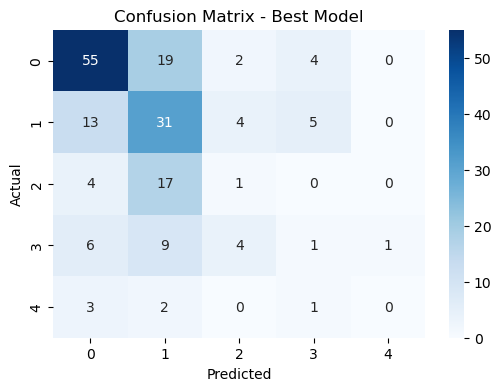

In [62]:
# Final Plots: Confusion Matrix and Tree Visualization
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.savefig('confusion_matrix.png')

**Decision Tree & Feature Importance:** Provide a "white-box" view of the model's logic and the relative importance of each health indicator.

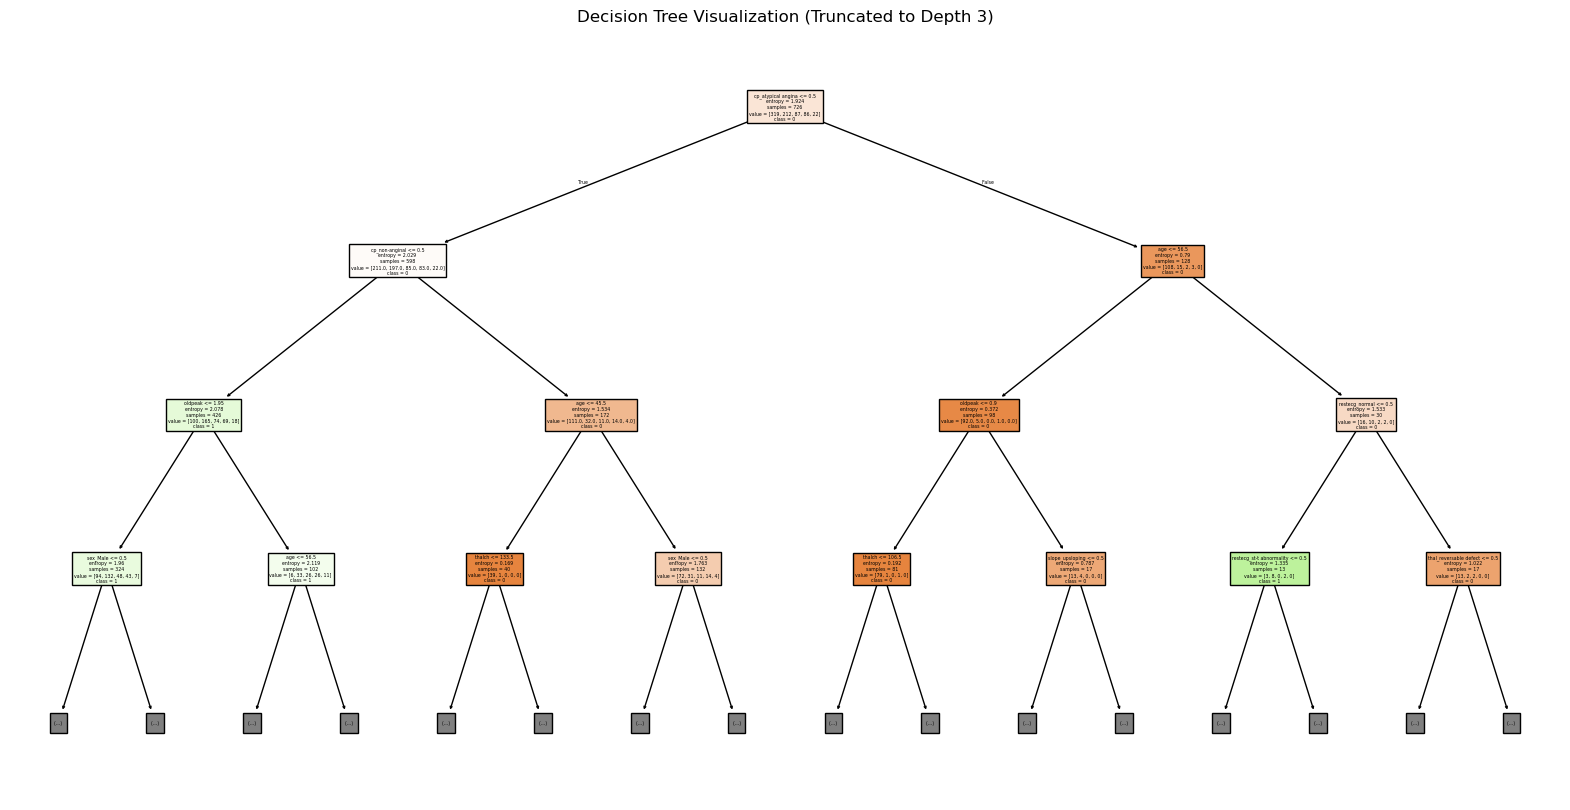

In [64]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())], filled=True, max_depth=3)
plt.title('Decision Tree Visualization (Truncated to Depth 3)')
plt.savefig('decision_tree.png')

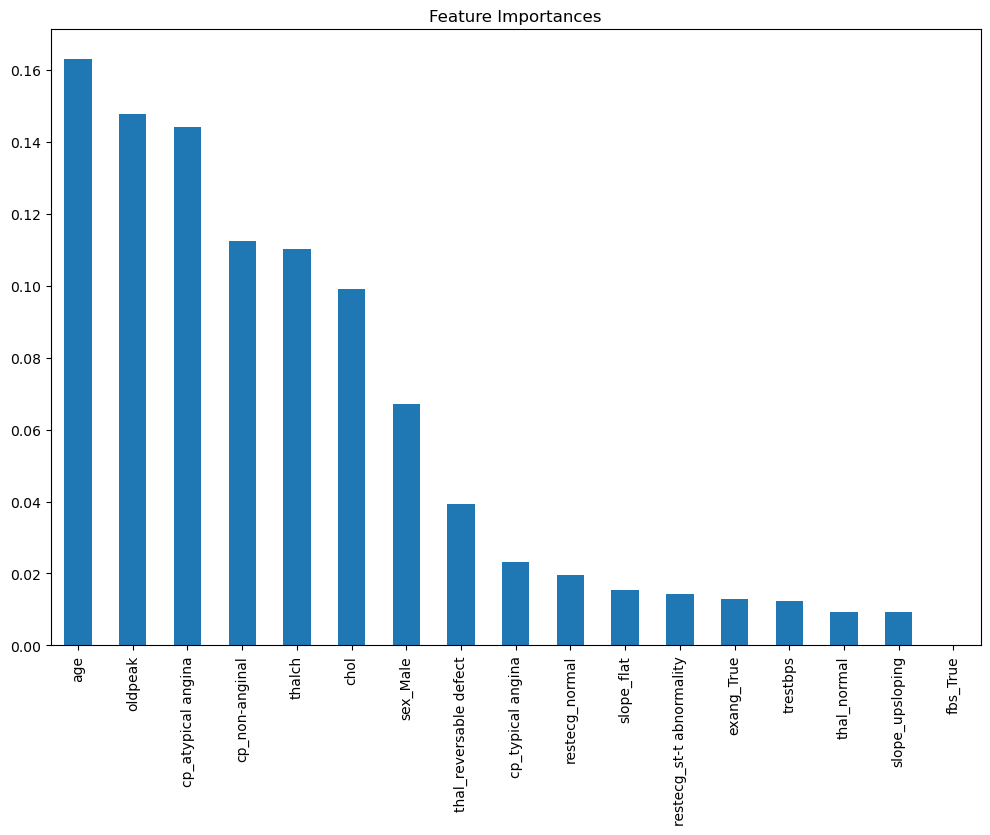

In [65]:
# Feature Importance
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
importances.plot(kind='bar')
plt.title('Feature Importances')
plt.savefig('feature_importance.png')

### Observations:

The model is very effective at identifying Class 0 (No Heart Disease), with a precision of ~68%.

Distinguishing between the specific stages (1, 2, 3, 4) is significantly more challenging due to overlapping feature distributions and smaller sample sizes for advanced stages.

Feature Importance: The most influential features in predicting heart disease stages were thal_normal, oldpeak, thalch, and age.

The processed data and model results indicate that while a basic Decision Tree can identify the presence of heart disease, more advanced ensemble methods (like Random Forests) might be required to accurately differentiate between the specific stages of the disease.